In [1]:
import scanpy as sc
from pathlib import Path
import os
import pandas as pd

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# construct WMB object

In [2]:
base_dir = '/Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630'
files = ['WMB-10Xv2-Isocortex-1-raw.h5ad',
 'WMB-10Xv2-OLF-raw.h5ad',
 'WMB-10Xv2-TH-raw.h5ad',
 'WMB-10Xv2-MB-raw.h5ad',
 'WMB-10Xv2-HY-raw.h5ad',
 'WMB-10Xv2-HPF-raw.h5ad']


In [3]:
os.listdir(base_dir)

['WMB-10Xv2-Isocortex-1-raw.h5ad',
 'WMB-10Xv2-OLF-raw.h5ad',
 'WMB-10Xv2-MB-raw_with_meta.h5ad',
 'WMB-10Xv2-CTXsp-raw.h5ad',
 'WMB10Xv2_selected_concat_balanced.h5ad',
 'WMB-10Xv2-TH-raw.h5ad',
 'WMB-10Xv2-Isocortex-2-raw.h5ad',
 'WMB-10Xv2-Isocortex-3-raw.h5ad',
 '.ipynb_checkpoints',
 'WMB-10Xv2-MB-raw.h5ad',
 'WMB10Xv2_selected_concat_small.h5ad',
 'WMB-10Xv2-HY-raw.h5ad',
 'WMB-10Xv2-HPF-raw.h5ad']

In [7]:
# ============================================
# Build single-cell AnnData from ABC atlas parts
# with balanced per-class sampling (RAM-safe)
# ============================================

import anndata as ad
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Optional

# ----------------------------
# CONFIG: adjust to your system
# ----------------------------
base_dir = "/Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630"
files = [
    "WMB-10Xv2-Isocortex-1-raw.h5ad",
    "WMB-10Xv2-HY-raw.h5ad",
    "WMB-10Xv2-TH-raw.h5ad",
    "WMB-10Xv2-MB-raw.h5ad",
       "WMB-10Xv2-CTXsp-raw.h5ad",
]

# Optional gene restriction; set to None to keep all common genes
genes_keep: Optional[list[str]] = None  # e.g., list of panel symbols
# Target label column to balance on (ABC atlas has "class_label")
class_key = "class_label"

# Per-file sampling budget (upper bound)
max_cells_per_file = 30_000

# Balancing strategy:
#   "proportional" -> allocates ~ proportionally but supports min/max caps and boosts
#   "equal"        -> same number per class (needs enough cells and total cap)
#   "cap"          -> per-class cap regardless of total (simple, robust)
balance_mode = "proportional"

# Class-specific knobs (tweak to fight skew)
min_per_class: Dict[str, int] = {
    "OPC-Oligo": 1000,    # guarantee at least this many if available
}
max_per_class: Dict[str, int] = {
    # "IT-ET Glut": 8000,  # example cap for dominant class
}
boost_weight: Dict[str, float] = {
    "OPC-Oligo": 3.0,     # favor OPC/Oligo in proportional allocation
}

# Reproducibility
RNG_SEED = 0

# Output
out_path = Path(base_dir) / "WMB10Xv2_selected_concat_balanced.h5ad"


# ----------------------------
# Helpers
# ----------------------------
def _proportional_indices(
    labels: np.ndarray,
    total_keep: int,
    rng: np.random.Generator,
    min_per: Optional[Dict[str, int]] = None,
    max_per: Optional[Dict[str, int]] = None,
    boost: Optional[Dict[str, float]] = None,
) -> np.ndarray:
    """Proportional per-class allocation with min/max caps and boost weights."""
    uniq, counts = np.unique(labels, return_counts=True)
    counts = counts.astype(float)

    # base weights (counts; optionally boosted for selected labels)
    w = counts.copy()
    if boost:
        w = np.array([w[i] * boost.get(uniq[i], 1.0) for i in range(len(uniq))], dtype=float)
    w_sum = w.sum()
    if w_sum == 0:
        return np.arange(0, dtype=int)

    # initial fractional allocation
    alloc = w / w_sum * total_keep
    base = np.floor(alloc).astype(int)
    remainder = total_keep - base.sum()
    # distribute remainder by largest fractional parts
    frac = alloc - base
    order = np.argsort(frac)[::-1]
    for i in order[:remainder]:
        base[i] += 1

    # apply min caps
    if min_per:
        for i, lab in enumerate(uniq):
            want = min_per.get(lab, 0)
            have = int((labels == lab).sum())
            base[i] = max(base[i], min(want, have))

    # apply max caps
    if max_per:
        for i, lab in enumerate(uniq):
            cap = max_per.get(lab, None)
            if cap is not None:
                base[i] = min(base[i], cap)

    # clamp to available counts
    avail = np.array([(labels == lab).sum() for lab in uniq], dtype=int)
    base = np.minimum(base, avail)

    # fix total if min/max pushed us off target
    diff = base.sum() - total_keep
    if diff != 0:
        if diff > 0:  # need to trim
            cand = np.where(base > 0)[0]
            # trim from smallest fractional priority first
            order = np.argsort(frac[cand])  # smallest fractional first
            for j in cand[order]:
                take = min(diff, base[j])
                base[j] -= take
                diff -= take
                if diff == 0:
                    break
        else:  # need to add
            diff = -diff
            cand = np.where(base < avail)[0]
            order = np.argsort(frac[cand])[::-1]  # largest fractional first
            for j in cand[order]:
                room = avail[j] - base[j]
                add = min(diff, room)
                base[j] += add
                diff -= add
                if diff == 0:
                    break

    # sample indices per label
    keep_idx = []
    for i, lab in enumerate(uniq):
        k = base[i]
        if k <= 0:
            continue
        lab_idx = np.where(labels == lab)[0]
        choose = rng.choice(lab_idx, size=k, replace=False)
        keep_idx.append(choose)

    return np.sort(np.concatenate(keep_idx)) if keep_idx else np.arange(0, dtype=int)


def _equal_indices(
    labels: np.ndarray,
    total_keep: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Equal per-class counts (limited by availability)."""
    uniq = pd.Index(pd.Categorical(labels).categories)
    K = len(uniq)
    per = max(1, total_keep // K)
    keep = []
    for lab in uniq:
        lab_idx = np.where(labels == lab)[0]
        k = min(per, lab_idx.size)
        if k > 0:
            keep.append(rng.choice(lab_idx, size=k, replace=False))
    return np.sort(np.concatenate(keep)) if keep else np.arange(0, dtype=int)


def _cap_indices(
    labels: np.ndarray,
    rng: np.random.Generator,
    min_per: int = 0,
    max_per: int = 5000,
) -> np.ndarray:
    """Per-class cap; keeps up to max_per per class (and at least min_per if available)."""
    cats = pd.Categorical(labels).categories
    keep = []
    for lab in cats:
        lab_idx = np.where(labels == lab)[0]
        n = lab_idx.size
        if n == 0:
            continue
        take = min(n, max_per)
        if take < min_per and n >= min_per:
            take = min_per
        keep.append(rng.choice(lab_idx, size=take, replace=False))
    return np.sort(np.concatenate(keep)) if keep else np.arange(0, dtype=int)


def concat_abca_parts(
    base_dir: str,
    files: list[str],
    genes_keep: Optional[list[str]] = None,
    class_key: Optional[str] = None,
    balance_mode: str = "proportional",  # "proportional" | "equal" | "cap"
    max_cells_per_file: Optional[int] = 50_000,
    min_per_class_for_cap: int = 0,
    max_per_class_for_cap: int = 5000,
    min_per_class_map: Optional[Dict[str, int]] = None,
    max_per_class_map: Optional[Dict[str, int]] = None,
    boost_weight_map: Optional[Dict[str, float]] = None,
    seed: int = 0,
) -> ad.AnnData:
    """Concatenate ABC atlas parts with balanced per-class downsampling."""
    paths = [Path(base_dir) / f for f in files]
    assert len(paths) > 0, "No input files provided"

    print("🔍 Finding common gene set ...")
    var_sets = []
    for p in paths:
        Ab = ad.read_h5ad(p, backed="r")
        var_sets.append(pd.Index(Ab.var_names.astype(str)))
        if getattr(Ab, "file", None) is not None:
            Ab.file.close()

    common_genes = var_sets[0]
    for v in var_sets[1:]:
        common_genes = common_genes.intersection(v)

    if genes_keep is not None:
        genes_keep = pd.Index(map(str, genes_keep))
        common_genes = common_genes.intersection(genes_keep)

    if len(common_genes) == 0:
        raise ValueError("No overlapping genes across selected files (after applying genes_keep).")
    print(f"✅ {len(common_genes)} common genes retained")

    rng = np.random.default_rng(seed)
    adatas = []

    for p in paths:
        print(f"📂 Loading: {p.name}")
        Ab = ad.read_h5ad(p, backed="r")
        n = Ab.n_obs

        if (max_cells_per_file is None) or (max_cells_per_file >= n):
            idx_keep = np.arange(n, dtype=int)
        else:
            if class_key and class_key in Ab.obs.columns:
                labels = Ab.obs[class_key].astype(str).to_numpy()
                if balance_mode == "proportional":
                    idx_keep = _proportional_indices(
                        labels,
                        total_keep=max_cells_per_file,
                        rng=rng,
                        min_per=min_per_class_map,
                        max_per=max_per_class_map,
                        boost=boost_weight_map,
                    )
                elif balance_mode == "equal":
                    idx_keep = _equal_indices(labels, total_keep=max_cells_per_file, rng=rng)
                elif balance_mode == "cap":
                    idx_keep = _cap_indices(labels, rng=rng,
                                            min_per=min_per_class_for_cap,
                                            max_per=max_per_class_for_cap)
                    # if too many overall, trim uniformly:
                    if idx_keep.size > max_cells_per_file:
                        idx_keep = np.sort(rng.choice(idx_keep, size=max_cells_per_file, replace=False))
                else:
                    raise ValueError(f"Unknown balance_mode: {balance_mode}")
            else:
                # fallback: uniform sampling (no class info)
                idx_keep = np.sort(rng.choice(n, size=max_cells_per_file, replace=False)).astype(int)

        # Build robust gene index (handles duplicate var names)
        var_index = pd.Index(Ab.var_names.astype(str))
        col_pos = var_index.get_indexer(common_genes)
        if np.any(col_pos < 0):
            missing = list(common_genes[np.where(col_pos < 0)[0][:10]])
            raise ValueError(f"Some common genes not found in {p.name}: {missing[:5]} ...")

        # Slice -> memory
        A_small = Ab[idx_keep, col_pos].to_memory()
        # Restore gene names (order = common_genes)
        A_small.var_names = pd.Index(common_genes, name=None)

        # Meta
        A_small.obs["source_file"] = p.name
        # optional sample id from prefix
        A_small.obs["sample_id"] = p.stem.split("-")[2] if "-" in p.stem else p.stem

        if getattr(Ab, "file", None) is not None:
            Ab.file.close()

        print(f"   → kept {A_small.n_obs:,} / {n:,} cells")
        adatas.append(A_small)

    print("🧩 Concatenating ...")
    A = ad.concat(adatas, axis=0, join="inner", merge="same")
    # safety: unique obs names
    A.obs_names_make_unique()
    print(f"✅ Concatenated AnnData: {A.shape[0]:,} cells × {A.shape[1]:,} genes")
    return A


# ----------------------------
# RUN
# ----------------------------
adata_ref_small = concat_abca_parts(
    base_dir=base_dir,
    files=files,
    genes_keep=genes_keep,
    class_key=class_key,
    balance_mode=balance_mode,              # "proportional" | "equal" | "cap"
    max_cells_per_file=max_cells_per_file,
    min_per_class_for_cap=0,                # used if balance_mode="cap"
    max_per_class_for_cap=5000,             # used if balance_mode="cap"
    min_per_class_map=min_per_class,        # used if balance_mode="proportional"
    max_per_class_map=max_per_class,        # used if balance_mode="proportional"
    boost_weight_map=boost_weight,          # used if balance_mode="proportional"
    seed=RNG_SEED,
)

# Quick view of class balance after concat (if class_key present)
if class_key in adata_ref_small.obs.columns:
    print("\nClass distribution (top 20):")
    print(adata_ref_small.obs[class_key].value_counts().head(20))

# ----------------------------
# SAVE
# ----------------------------
adata_ref_small.write(out_path, compression="gzip")
print(f"💾 Saved to {out_path}")

🔍 Finding common gene set ...
✅ 32285 common genes retained
📂 Loading: WMB-10Xv2-Isocortex-1-raw.h5ad
   → kept 30,000 / 250,040 cells
📂 Loading: WMB-10Xv2-HY-raw.h5ad
   → kept 30,000 / 100,562 cells
📂 Loading: WMB-10Xv2-TH-raw.h5ad
   → kept 30,000 / 131,212 cells
📂 Loading: WMB-10Xv2-MB-raw.h5ad
   → kept 29,891 / 29,891 cells
📂 Loading: WMB-10Xv2-CTXsp-raw.h5ad
   → kept 30,000 / 44,310 cells
🧩 Concatenating ...
✅ Concatenated AnnData: 149,891 cells × 32,285 genes
💾 Saved to /Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB10Xv2_selected_concat_balanced.h5ad


In [13]:
adata_ref_small.var = adata_ref_small.var.set_index('gene_symbol')

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [14]:
df = pd.read_excel('/Users/christoffer/Downloads/cl.df_CCN202307220.xlsx')

In [15]:
meta = pd.read_csv('/Users/christoffer/work/karolinska/development/data/abc_atlas/metadata/WMB-10X/20241115/cell_metadata.csv')

In [16]:
adata_ref_small.obs['cluster_alias'] = adata_ref_small.obs.index.map(dict(zip(meta['cell_label'],meta['cluster_alias'])))

In [17]:
adata_ref_small.obs['class_label'] = adata_ref_small.obs['cluster_alias'].map(dict(zip(df['cluster_id'].astype(float), df.class_label)))

In [18]:
adata_ref_small.obs

,cell_barcode,library_label,anatomical_division_label,source_file,sample_id,cluster_alias,class_label
cell_label,,,,,,,
CGTGTAACAAGAAGAG-099_A01,CGTGTAACAAGAAGAG,L8TX_190312_01_E02,Isocortex,WMB-10Xv2-Isocortex-1-raw.h5ad,Isocortex,10.0,IT-ET Glut
TGTATTCAGCGATATA-099_C01,TGTATTCAGCGATATA,L8TX_190312_01_F02,Isocortex,WMB-10Xv2-Isocortex-1-raw.h5ad,Isocortex,10.0,IT-ET Glut
TTCGGTCTCAGTTGAC-099_C01,TTCGGTCTCAGTTGAC,L8TX_190312_01_F02,Isocortex,WMB-10Xv2-Isocortex-1-raw.h5ad,Isocortex,10.0,IT-ET Glut
CAAGAAAAGAAGGCCT-1.17_C01,CAAGAAAAGAAGGCCT,L8TX_180115_01_A10,Isocortex,WMB-10Xv2-Isocortex-1-raw.h5ad,Isocortex,100.0,IT-ET Glut
GCTTGAACAAACCCAT-022_B01,GCTTGAACAAACCCAT,L8TX_180406_01_F02,Isocortex,WMB-10Xv2-Isocortex-1-raw.h5ad,Isocortex,100.0,IT-ET Glut
...,...,...,...,...,...,...,...
ATTACTCGTAGTACCT-120_B01,ATTACTCGTAGTACCT,L8TX_190528_01_C10,CTXsp,WMB-10Xv2-CTXsp-raw.h5ad,CTXsp,5254.0,Astro-Epen
ATTATCCAGCTGCCCA-120_B01,ATTATCCAGCTGCCCA,L8TX_190528_01_C10,CTXsp,WMB-10Xv2-CTXsp-raw.h5ad,CTXsp,5254.0,Astro-Epen
AAGCCGCGTGCAACGA-079_B01,AAGCCGCGTGCAACGA,L8TX_190116_01_D04,CTXsp,WMB-10Xv2-CTXsp-raw.h5ad,CTXsp,5254.0,Astro-Epen


In [19]:
# Quick view of class balance after concat (if class_key present)
if class_key in adata_ref_small.obs.columns:
    print("\nClass distribution (top 20):")
    print(adata_ref_small.obs[class_key].value_counts().head(20))



Class distribution (top 20):
class_label
IT-ET Glut        34537
MY GABA           23473
Astro-Epen        16357
MB GABA           12949
HY GABA            9465
NP-CT-L6b Glut     8110
CNU-HYa GABA       7964
CNU-HYa Glut       6742
HY Glut            6009
MB Glut            4302
CTX-CGE GABA       3937
OB-IMN GABA        3133
P GABA             2701
CB Glut            2698
DG-IMN Glut         930
MY Glut             919
CTX-MGE GABA        796
OB-CR Glut          782
LSX GABA            725
MH-LH Glut          321
Name: count, dtype: int64


In [103]:
adata_ref_small.write('../data/ABC_WBA_subset.h5ad')

In [20]:
adata_ref_small = sc.read_h5ad('/Users/christoffer/work/karolinska/development/ST_BRICHOS/data/linnarsson_adolescence_full.h5ad')

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [56]:
adata_ref_small.obs.Class.value_counts()

Class
Neurons           74539
Oligos            31073
Astrocytes        22491
Vascular          12196
PeripheralGlia    11217
Immune             7454
Ependymal          1826
Name: count, dtype: int64

In [57]:
import numpy as np
import pandas as pd

def sample_to_targets(
    adata,
    class_key="Class",
    targets=None,              # dict: {"Neurons":12000, "Oligos":12000, ...}
    total_budget=None,         # alternatively: int, used with target_proportions
    target_proportions=None,   # dict of proportions summing to 1.0
    seed=0,
    stratify_key="source_file" # keep mix across files within each class; set None to disable
):
    """
    Return a balanced AnnData according to targets or (total_budget * target_proportions).
    """
    if targets is None:
        if total_budget is None or target_proportions is None:
            raise ValueError("Provide either `targets` or (`total_budget` & `target_proportions`).")
        # build integer targets from proportions
        props = pd.Series(target_proportions, dtype=float)
        props = props / props.sum()
        targets = (props * total_budget).round().astype(int).to_dict()

    rng = np.random.default_rng(seed)
    classes = pd.Categorical(adata.obs[class_key]).categories
    keep_idx_all = []

    for cls, goal in targets.items():
        # all cells of this class
        cls_mask = (adata.obs[class_key].astype(str).values == cls)
        cls_idx = np.where(cls_mask)[0]
        if cls_idx.size == 0:
            print(f"⚠️ no cells for class '{cls}', skipping")
            continue

        goal = int(min(goal, cls_idx.size))  # can’t sample more than available
        if goal <= 0:
            continue

        if stratify_key is None or stratify_key not in adata.obs.columns:
            # simple random sample within class
            chosen = rng.choice(cls_idx, size=goal, replace=False)
            keep_idx_all.append(chosen)
            print(f"{cls:>15s}: kept {goal}/{cls_idx.size} (no strat)")
            continue

        # proportional across strata (e.g., source_file) to keep regional diversity
        strata = pd.Categorical(adata.obs.loc[cls_idx, stratify_key]).categories
        # counts per stratum
        df = pd.DataFrame({
            "stratum": adata.obs.loc[cls_idx, stratify_key].values
        })
        counts = df["stratum"].value_counts()
        # alloc per stratum ~ proportional to availability
        alloc = (counts / counts.sum() * goal).astype(int)
        # hand out remaining by largest fractional parts
        frac = (counts / counts.sum() * goal) - alloc
        rem = goal - alloc.sum()
        if rem > 0:
            for s in frac.sort_values(ascending=False).index[:rem]:
                alloc[s] += 1

        chosen = []
        for s, k in alloc.items():
            pool = cls_idx[df["stratum"].values == s]
            if k > 0 and pool.size > 0:
                k = min(k, pool.size)
                chosen.append(rng.choice(pool, size=k, replace=False))
        if chosen:
            chosen = np.concatenate(chosen)
            keep_idx_all.append(chosen)
        print(f"{cls:>15s}: kept {len(chosen) if isinstance(chosen, np.ndarray) else 0}/{cls_idx.size} across {len(counts)} strata")

    if not keep_idx_all:
        raise RuntimeError("No cells selected; check your targets.")
    keep_idx_all = np.sort(np.concatenate(keep_idx_all))
    return adata[keep_idx_all].copy()

# --- Example targets (tune to taste / RAM) ---
targets = {
    "Neurons":        12000,   # cap hard
    "Oligos":         12000,   # boost
    "Astrocytes":      8000,
    "Ependymal":       3000,
    "Vascular":        6000,
    "PeripheralGlia":  4000,
    "Immune":          4000,
}

# Build a balanced reference
adata_ref_bal = sample_to_targets(
    adata_ref_small,           # your concatenated single-cell AnnData
    class_key="Class",
    targets=targets,
    seed=1,
    stratify_key="source_file" # keeps per-class regional diversity
)

# Quick check
print(adata_ref_bal.obs["Class"].value_counts())

# (optional) Also cap any ultra-dominant fine labels inside Neurons:
def cap_within_class(adata, class_key="Class", target_class="Neurons",
                     fine_key="class_label", per_fine_max=3000, seed=0):
    rng = np.random.default_rng(seed)
    mask = (adata.obs[class_key] == target_class)
    idx = np.where(mask.values)[0]
    keep = []
    for lab, sub_idx in adata.obs.iloc[idx].groupby(fine_key).groups.items():
        sub_idx = np.array(idx[list(sub_idx)], dtype=int)
        k = min(per_fine_max, sub_idx.size)
        keep.append(rng.choice(sub_idx, size=k, replace=False))
    keep = np.sort(np.concatenate(keep)) if keep else np.array([], int)
    other = np.where(~mask.values)[0]
    return adata[np.sort(np.concatenate([keep, other]))].copy()

# Example: cap neuron subclasses if needed
# adata_ref_bal = cap_within_class(adata_ref_bal, "Class", "Neurons", "class_label", per_fine_max=3000, seed=2)

        Neurons: kept 12000/74539 (no strat)
         Oligos: kept 12000/31073 (no strat)
     Astrocytes: kept 8000/22491 (no strat)
      Ependymal: kept 1826/1826 (no strat)
       Vascular: kept 6000/12196 (no strat)
 PeripheralGlia: kept 4000/11217 (no strat)
         Immune: kept 4000/7454 (no strat)
Class
Neurons           12000
Oligos            12000
Astrocytes         8000
Vascular           6000
Immune             4000
PeripheralGlia     4000
Ependymal          1826
Name: count, dtype: int64


In [76]:
adata_ref_bal.obs

,Class,region_macro,_scvi_batch,_scvi_labels,cell_type
CellID,,,,,
10X81_2:CGTAACATTCGACA,Neurons,Enteric NS,0,3,Neurons
10X82_2:ATGGCAGAGGTTAT,Neurons,Enteric NS,0,3,Neurons
10X81_3:TTGAAAGCAGCCTC,Neurons,Enteric NS,0,3,Neurons
10X82_2:GGTGCGTGTTTGTG,Neurons,Enteric NS,0,3,Neurons
10X81_1:CCTTGTCTCGTATT,Neurons,Enteric NS,0,3,Neurons
...,...,...,...,...,...
10X43_2:AGCACTGATGACCA,Neurons,DRG,0,3,Neurons
10X43_2:AGGCTAACTGTCAG,Neurons,DRG,0,3,Neurons
10X43_2:TTATTCCTACTTTC,Neurons,DRG,0,3,Neurons


In [77]:
adata_ref_small = adata_ref_bal.copy()

In [78]:
adata_ref_small.obs_names_make_unique()
adata_ref_small.var_names_make_unique()

# read spatial data

In [79]:
adata_sp = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad') 

# set up scvi-tools

In [30]:
import scvi, scanpy as sc


In [80]:
adata_sp.X  = adata_sp.layers['counts'].copy()

In [81]:
adata_sp.var

,n_cells
Xkr4,6886
Rp1,165
Sox17,4046
Lypla1,10685
Tcea1,18318
...,...
Arhgap6,5752
Hccs,13372
Mid1,2834
4933400A11Rik,10


In [82]:
adata_ref_small.obs

,Class,region_macro,_scvi_batch,_scvi_labels,cell_type
CellID,,,,,
10X81_2:CGTAACATTCGACA,Neurons,Enteric NS,0,3,Neurons
10X82_2:ATGGCAGAGGTTAT,Neurons,Enteric NS,0,3,Neurons
10X81_3:TTGAAAGCAGCCTC,Neurons,Enteric NS,0,3,Neurons
10X82_2:GGTGCGTGTTTGTG,Neurons,Enteric NS,0,3,Neurons
10X81_1:CCTTGTCTCGTATT,Neurons,Enteric NS,0,3,Neurons
...,...,...,...,...,...
10X43_2:AGCACTGATGACCA,Neurons,DRG,0,3,Neurons
10X43_2:AGGCTAACTGTCAG,Neurons,DRG,0,3,Neurons
10X43_2:TTATTCCTACTTTC,Neurons,DRG,0,3,Neurons


In [83]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse

def _collapse_duplicate_genes(adata: ad.AnnData, gene_col: str = None, how: str = "sum") -> ad.AnnData:
    """
    Ensure unique genes by collapsing duplicates.
    - If gene_col provided and present in .var, use that column as gene symbol source.
    - Otherwise use current .var_names.
    - Aggregation: 'sum' (default) or 'mean'
    """
    A = adata
    V = A.var.copy()

    # Pick gene key
    if gene_col is not None and gene_col in V.columns:
        genes = V[gene_col].astype(str).values
    else:
        genes = A.var_names.astype(str).values

    # Group indices by gene
    df = pd.DataFrame({"gene": genes})
    groups = df.groupby("gene").indices  # dict: gene -> row indices in var

    # If already unique, just normalize and return
    if all(len(ix) == 1 for ix in groups.values()):
        A = A.copy()
        A.var_names = pd.Index(genes, name=None)
        A.var_names_make_unique()  # safety (should already be unique)
        return A

    # Aggregate columns for duplicates
    keep_genes, cols = [], []
    if sparse.issparse(A.X):
        X = A.X.tocsc()  # aggregate by columns
    else:
        X = np.asarray(A.X)

    for g, ix in groups.items():
        ix = np.array(sorted(ix))
        if len(ix) == 1:
            col = X[:, ix[0]]
        else:
            if sparse.issparse(X):
                cols_to_stack = [X[:, j] for j in ix]
                col = cols_to_stack[0]
                if how == "sum":
                    for c in cols_to_stack[1:]:
                        col = col + c
                elif how == "mean":
                    for c in cols_to_stack[1:]:
                        col = col + c
                    col = col / len(ix)
                else:
                    raise ValueError("how must be 'sum' or 'mean'")
            else:
                sub = X[:, ix]
                col = sub.sum(axis=1) if how == "sum" else sub.mean(axis=1)

        cols.append(col)
        keep_genes.append(g)

    # Stack back to matrix
    if sparse.issparse(X):
        X_new = sparse.hstack(cols, format="csc")
    else:
        X_new = np.column_stack([c.A.ravel() if sparse.issparse(c) else np.ravel(c) for c in cols])

    # Build new AnnData with unique gene names
    A_new = ad.AnnData(X_new, obs=A.obs.copy(), var=pd.DataFrame(index=pd.Index(keep_genes, name=None)))
    # Preserve layers (collapsed the same way)
    for lname, layer in (A.layers or {}).items():
        if sparse.issparse(layer):
            L = layer.tocsc()
            new_cols = []
            for g, ix in groups.items():
                ix = np.array(sorted(ix))
                if len(ix) == 1:
                    new_cols.append(L[:, ix[0]])
                else:
                    col = L[:, ix[0]]
                    if how == "sum":
                        for c in ix[1:]:
                            col = col + L[:, c]
                    else:
                        tmp = L[:, ix[0]]
                        for c in ix[1:]:
                            tmp = tmp + L[:, c]
                        col = tmp / len(ix)
                    new_cols.append(col)
            A_new.layers[lname] = sparse.hstack(new_cols, format="csc")
        else:
            arr = np.asarray(layer)
            new_cols = []
            for g, ix in groups.items():
                ix = np.array(sorted(ix))
                sub = arr[:, ix]
                new_cols.append(sub.sum(axis=1) if how == "sum" else sub.mean(axis=1))
            A_new.layers[lname] = np.column_stack(new_cols)

    # Keep useful var columns if gene_col existed
    if gene_col is not None and gene_col in A.var.columns:
        A_new.var[gene_col] = A_new.var_names

    return A_new

def harmonize_and_intersect_genes(adata_ref: ad.AnnData, adata_sp: ad.AnnData,
                                  preferred_var_col: str | None = None):
    """
    1) Collapse duplicate genes in both datasets (using preferred_var_col if present, e.g., 'gene_symbol'/'feature_name').
    2) Intersect gene sets and return aligned copies.
    """
    Aref = _collapse_duplicate_genes(adata_ref, gene_col=preferred_var_col, how="sum")
    Asp  = _collapse_duplicate_genes(adata_sp,  gene_col=preferred_var_col, how="sum")

    # final safety: ensure unique
    Aref.var_names = Aref.var_names.astype(str); Aref.var_names_make_unique()
    Asp.var_names  = Asp.var_names.astype(str);  Asp.var_names_make_unique()

    common = np.intersect1d(Aref.var_names, Asp.var_names)
    if len(common) == 0:
        raise ValueError("No overlapping genes after harmonization. Check gene symbols/case/ensembl IDs.")
    if len(common) < 200:
        print(f"⚠️ Only {len(common)} common genes.")

    Aref2 = Aref[:, common].copy()
    Asp2  = Asp[:, common].copy()
    return Aref2, Asp2

In [84]:
# If your .var has a column with symbols, pass it (e.g., 'gene_symbol', 'feature_name', or 'Gene Symbol')
adata_ref_small, adata_sp = harmonize_and_intersect_genes(
    adata_ref_small,
    adata_sp,
    preferred_var_col=None  # or e.g., 'feature_name'
)

In [85]:
import os
os.environ["PL_ACCELERATOR"] = "mps"      # belt & suspenders

In [86]:

import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import torch
import scvi
from lightning.pytorch.callbacks import Callback

In [87]:
import torch
print("PyTorch version:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())
print("CUDA available:", torch.cuda.is_available())  # should be False on mac

PyTorch version: 2.9.0
MPS built: True
MPS available: True
CUDA available: False


In [101]:
import os, time, torch, scvi
from lightning.pytorch.callbacks import Callback
from scipy.sparse import issparse, csr_matrix

# 0) Safer default
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# 1) Make counts CSR
def ensure_counts_csr(adata, layer="counts"):
    if layer not in adata.layers:
        adata.layers[layer] = adata.X
    adata.layers[layer] = adata.layers[layer].tocsr() if issparse(adata.layers[layer]) else csr_matrix(adata.layers[layer])

ensure_counts_csr(adata_ref_small, "counts")
scvi.model.SCVI.setup_anndata(adata_ref_small, layer="counts")

# 2) Loud, MPS-friendly callbacks
class MPSHeartbeat(Callback):
    def on_fit_start(self, trainer, pl_module):
        print("🔊 fit_start; device:", next(pl_module.parameters()).device)
    def on_train_epoch_start(self, trainer, pl_module):
        print(f"\n🚀 epoch {trainer.current_epoch+1}/{trainer.max_epochs} | device={next(pl_module.parameters()).device}")
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if (batch_idx + 1) % 50 == 0:
            if torch.backends.mps.is_available():
                torch.mps.synchronize()
            print(f"[{time.strftime('%H:%M:%S')}] batch {batch_idx+1}")

def set_dl_workers(n: int):
    """Configure scvi dataloader workers safely for macOS."""
    scvi.settings.dl_num_workers = n
    try:
        scvi.settings.dl_persistent_workers = n > 0  # must be False when n=0
        scvi.settings.dl_pin_memory = False          # CUDA-only; keep False on MPS
    except Exception:
        pass

set_dl_workers(0)  # start stable; you can try 2–4 later
# 3) Trainer args (pass **directly**, no trainer_kwargs)
TRAINER_KW = dict(
    accelerator="mps",
    devices=1,
    precision="32-true",
    enable_progress_bar=True,
    callbacks=[MPSHeartbeat()],
    log_every_n_steps=1,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

scvi.settings.dl_num_workers = 0   # start safe on macOS; try 2–4 later

# 4) Quick SCVI train (few epochs) to see MPS work
m_ref = scvi.model.SCVI(adata_ref_small, n_latent=40,
    n_hidden=256,
    n_layers=2,
    gene_likelihood="zinb",
    dispersion="gene-batch")
m_ref.train(max_epochs=3, **TRAINER_KW)



GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


🔊 fit_start; device: mps:0


Training:   0%|          | 0/3 [00:00<?, ?it/s]


🚀 epoch 1/3 | device=mps:0
[14:42:12] batch 50
[14:42:13] batch 100
[14:42:13] batch 150
[14:42:14] batch 200
[14:42:15] batch 250
[14:42:15] batch 300

🚀 epoch 2/3 | device=mps:0
[14:42:17] batch 50
[14:42:17] batch 100
[14:42:18] batch 150
[14:42:19] batch 200
[14:42:19] batch 250
[14:42:20] batch 300

🚀 epoch 3/3 | device=mps:0
[14:42:21] batch 50
[14:42:22] batch 100
[14:42:22] batch 150
[14:42:23] batch 200
[14:42:24] batch 250
[14:42:24] batch 300


`Trainer.fit` stopped: `max_epochs=3` reached.


In [102]:
print("Model device:", m_ref.module.device)

Model device: mps:0


In [103]:
adata_ref_small.obs

,Class,region_macro,_scvi_batch,_scvi_labels,cell_type
CellID,,,,,
10X81_2:CGTAACATTCGACA,Neurons,Enteric NS,0,0,Neurons
10X82_2:ATGGCAGAGGTTAT,Neurons,Enteric NS,0,0,Neurons
10X81_3:TTGAAAGCAGCCTC,Neurons,Enteric NS,0,0,Neurons
10X82_2:GGTGCGTGTTTGTG,Neurons,Enteric NS,0,0,Neurons
10X81_1:CCTTGTCTCGTATT,Neurons,Enteric NS,0,0,Neurons
...,...,...,...,...,...
10X43_2:AGCACTGATGACCA,Neurons,DRG,0,0,Neurons
10X43_2:AGGCTAACTGTCAG,Neurons,DRG,0,0,Neurons
10X43_2:TTATTCCTACTTTC,Neurons,DRG,0,0,Neurons


In [104]:
m_ref

SCVI model with the following parameters: 
n_hidden: 256, n_latent: 40, n_layers: 2, dropout_rate: 0.1, dispersion: gene-batch, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

In [105]:
# === SCANVI on MPS: sanitize labels, train, predict ===
import os, numpy as np, pandas as pd, scvi
from scipy.sparse import issparse, csr_matrix

# ---- GPU/MPS-safe dataloader settings (macOS) ----
def set_dl_workers(n: int):
    scvi.settings.dl_num_workers = n
    try:
        scvi.settings.dl_persistent_workers = n > 0  # must be False if n==0
        scvi.settings.dl_pin_memory = False          # CUDA-only; keep False on MPS
    except Exception:
        pass

set_dl_workers(0)                     # start stable; try 2–4 later
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# ---- ensure counts are CSR before setup_anndata ----
def ensure_counts_csr(adata, layer="counts"):
    if layer not in adata.layers:
        adata.layers[layer] = adata.X
    adata.layers[layer] = adata.layers[layer].tocsr() if issparse(adata.layers[layer]) else csr_matrix(adata.layers[layer])

ensure_counts_csr(adata_ref_small, "counts")

# ---- sanitize labels + merge ultra-rare into 'Unknown' ----
label_col = "Class"         # <- change if your label key is different
dst_col   = "cell_type"
UNLABELED = "Unknown"
MIN_CELLS = 5                      # merge classes with <5 cells

def sanitize_labels_for_scanvi(adata, src_col=label_col, dst_col=dst_col, unlabeled=UNLABELED, min_cells=MIN_CELLS):
    s = adata.obs[src_col].astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan}).fillna(unlabeled)
    # merge rare labels to 'Unknown'
    vc = s.value_counts()
    rare = set(vc[vc < min_cells].index)
    if rare:
        print(f"Merging {len(rare)} rare labels (<{min_cells} cells) into '{unlabeled}': {sorted(list(rare))[:10]} ...")
    s = s.where(~s.isin(rare), unlabeled)

    cats = pd.Index(sorted(pd.unique(s)))
    if unlabeled not in cats:
        cats = cats.insert(len(cats), unlabeled)
    adata.obs[dst_col] = pd.Categorical(s, categories=cats)

    print("Label counts (top 12):\n", adata.obs[dst_col].value_counts().head(12))

sanitize_labels_for_scanvi(adata_ref_small, src_col=label_col, dst_col=dst_col, unlabeled=UNLABELED)

# ---- SCANVI from pretrained SCVI (m_ref) ----
# assumes you already trained: m_ref = scvi.model.SCVI(adata_ref_small, n_latent=30); m_ref.train(...)
scvi.model.SCANVI.setup_anndata(
    adata_ref_small,
    labels_key=dst_col,
    unlabeled_category=UNLABELED,
)

scanvi = scvi.model.SCANVI.from_scvi_model(
    m_ref,
    labels_key=dst_col,
    unlabeled_category=UNLABELED,
)
from lightning.pytorch.callbacks import Callback
from datetime import datetime

class BatchVerboseCallback(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        loss = outputs.get("loss", None)
        now = datetime.now().strftime("%H:%M:%S")
        if loss is not None:
            print(f"[{now}] Epoch {trainer.current_epoch+1}, batch {batch_idx+1}/{len(trainer.train_dataloader)} — loss={loss:.4f}")

verbose_cb = BatchVerboseCallback()
# train on MPS (bigger batch for throughput) — batch_size is TOP-LEVEL
scanvi.train(
    max_epochs=20,
    batch_size=4096,
    accelerator="mps",
    devices=1,
    precision="32-true",
    enable_progress_bar=True,
    log_every_n_steps=1,
    num_sanity_val_steps=0,
    enable_model_summary=False,
    callbacks=[verbose_cb],     # 👈 added here
)
# ---- predict on spatial ----
# make sure gene spaces already intersect; ensure CSR counts on spatial too:
ensure_counts_csr(adata_sp, "counts")
scvi.model.SCVI.setup_anndata(adata_sp, layer="counts")



Label counts (top 12):
 cell_type
Neurons           12000
Oligos            12000
Astrocytes         8000
Vascular           6000
Immune             4000
PeripheralGlia     4000
Ependymal          1826
Unknown               0
Name: count, dtype: int64
INFO     Training for 20 epochs.                                                                                   


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/20 [00:00<?, ?it/s]

[14:42:30] Epoch 1, batch 1/11 — loss=4012.6167
[14:42:31] Epoch 1, batch 2/11 — loss=3994.3567
[14:42:31] Epoch 1, batch 3/11 — loss=3936.0591
[14:42:31] Epoch 1, batch 4/11 — loss=3874.1038
[14:42:31] Epoch 1, batch 5/11 — loss=3879.0505
[14:42:32] Epoch 1, batch 6/11 — loss=3855.6682
[14:42:32] Epoch 1, batch 7/11 — loss=3821.4907
[14:42:32] Epoch 1, batch 8/11 — loss=3814.3923
[14:42:33] Epoch 1, batch 9/11 — loss=3852.9187
[14:42:33] Epoch 1, batch 10/11 — loss=3799.9458
[14:42:34] Epoch 1, batch 11/11 — loss=3815.3447
[14:42:34] Epoch 2, batch 1/11 — loss=3783.5981
[14:42:34] Epoch 2, batch 2/11 — loss=3815.6902
[14:42:35] Epoch 2, batch 3/11 — loss=3751.6426
[14:42:35] Epoch 2, batch 4/11 — loss=3859.8779
[14:42:35] Epoch 2, batch 5/11 — loss=3819.8516
[14:42:35] Epoch 2, batch 6/11 — loss=3804.1213
[14:42:36] Epoch 2, batch 7/11 — loss=3795.9585
[14:42:36] Epoch 2, batch 8/11 — loss=3770.1733
[14:42:36] Epoch 2, batch 9/11 — loss=3774.0938
[14:42:37] Epoch 2, batch 10/11 — loss

`Trainer.fit` stopped: `max_epochs=20` reached.


[14:43:32] Epoch 20, batch 10/11 — loss=3703.3167
[14:43:32] Epoch 20, batch 11/11 — loss=3694.2854


In [106]:
import pandas as pd
from scipy.sparse import issparse, csr_matrix

# 1) ensure counts layer exists & is CSR
def ensure_counts_csr(adata, layer="counts"):
    if layer not in adata.layers:
        adata.layers[layer] = adata.X
    adata.layers[layer] = adata.layers[layer].tocsr() if issparse(adata.layers[layer]) else csr_matrix(adata.layers[layer])

ensure_counts_csr(adata_sp, "counts")

# 2) make sure genes are already intersected with reference (you said you did this)
# adata_ref_small, adata_sp = harmonize_and_intersect(adata_ref_small, adata_sp)

# 3) create 'cell_type' in adata_sp with the same categories as the reference SCANVI used
ref_cats = adata_ref_small.obs["cell_type"].cat.categories
adata_sp.obs["cell_type"] = pd.Categorical(
    ["Unknown"] * adata_sp.n_obs,
    categories=ref_cats
)

# 4) setup anndata for the target with same layer + labels_key
scvi.model.SCANVI.setup_anndata(
    adata_sp,
    labels_key="cell_type",
    unlabeled_category="Unknown",
    layer="counts",
)

# 5) now predict
pred_labels = scanvi.predict(adata_sp)        # pd.Series
import pandas as pd
import numpy as np

# ensure the target AnnData is set up (as you already did)
# scvi.model.SCANVI.setup_anndata(adata_sp, labels_key="cell_type", unlabeled_category="Unknown", layer="counts")

# hard labels (pd.Series)
pred_labels = scanvi.predict(adata_sp, soft=False)

# probabilities (numpy array or DataFrame depending on version)
probas = scanvi.predict(adata_sp, soft=True)

# make a DataFrame with sensible column names
if isinstance(probas, np.ndarray):
    # use the reference label order as column names
    cls = list(adata_ref_small.obs["cell_type"].cat.categories)
    # trim in case of mismatch in length
    cls = cls[:probas.shape[1]]
    pred_probas = pd.DataFrame(probas, index=adata_sp.obs_names, columns=cls)
else:
    pred_probas = probas  # already a DataFrame

# store results
adata_sp.obs["pred_celltype"]   = pd.Series(pred_labels, index=adata_sp.obs_names).astype(str)
adata_sp.obs["pred_confidence"] = pred_probas.max(axis=1).values
adata_sp.obsm["scanvi_probas"]  = pred_probas.values
adata_sp.uns["scanvi_probas_cols"] = list(pred_probas.columns)

print("✅ Wrote predictions: obs['pred_celltype'], obs['pred_confidence'], obsm['scanvi_probas'], uns['scanvi_probas_cols']")

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
✅ Wrote predictions: obs['pred_celltype'], obs['pred_confidence'], obsm['scanvi_probas'], uns['scanvi_probas_cols']


In [107]:
adata_sp.obs.pred_celltype.value_counts()

pred_celltype
Neurons       25333
Vascular        120
Ependymal       108
Astrocytes       74
Oligos           24
Immune            1
Name: count, dtype: int64

In [108]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

Plotting pred_celltype …


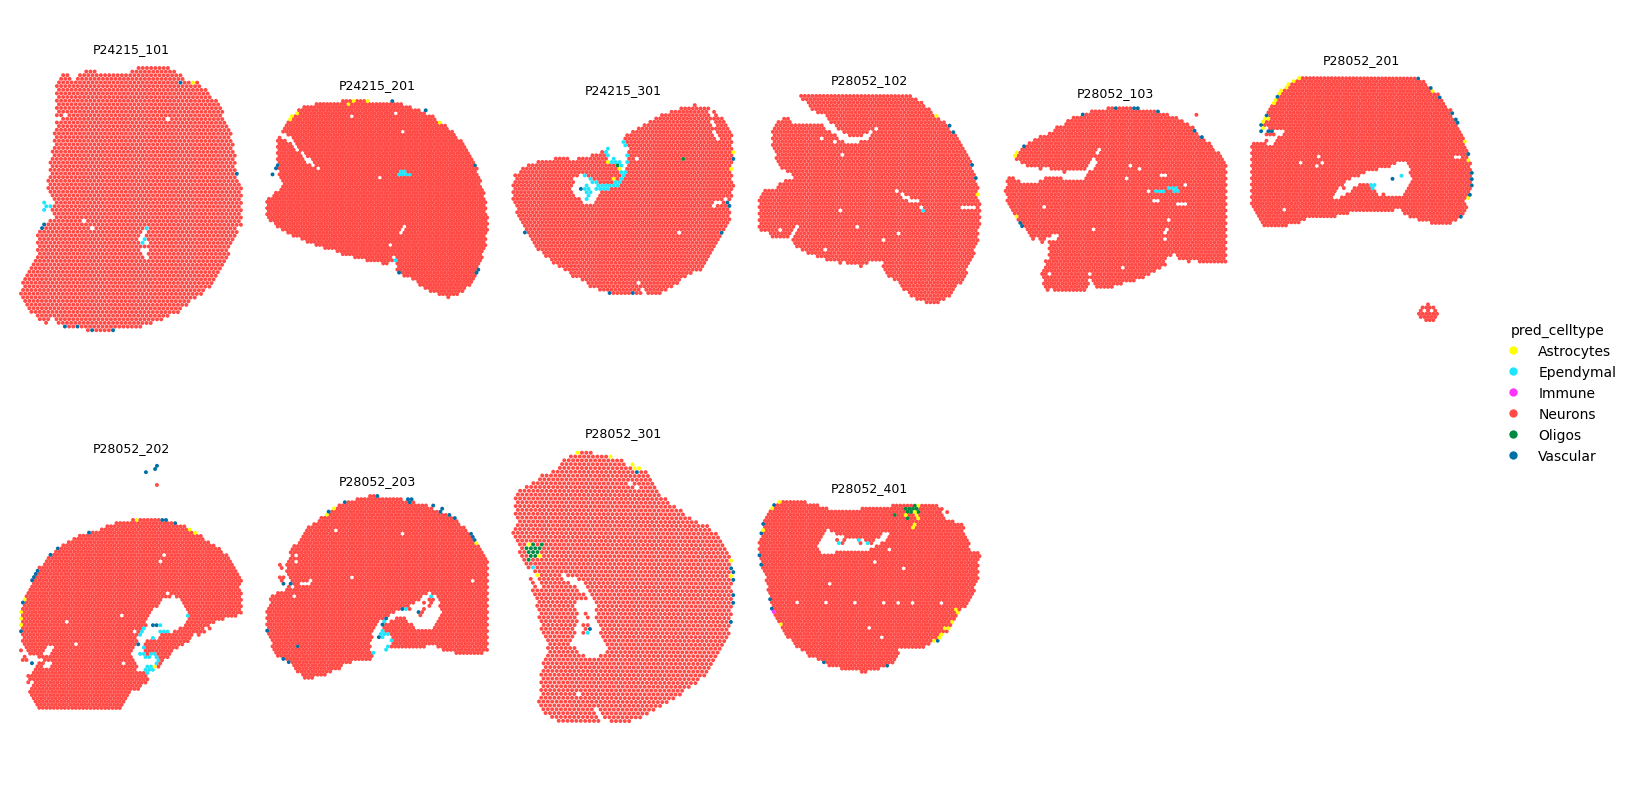

In [109]:
for domain in ['pred_celltype']:
    if domain in adata_sp.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata_sp,
            color=domain,
            groupby="sample_id",
            spot_size=8,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [110]:
adata_sp.obs.pred_celltype.value_counts()

pred_celltype
Neurons       25333
Vascular        120
Ependymal       108
Astrocytes       74
Oligos           24
Immune            1
Name: count, dtype: int64

In [111]:
adata_ref_small.obs.Class.value_counts()

Class
Neurons           12000
Oligos            12000
Astrocytes         8000
Vascular           6000
Immune             4000
PeripheralGlia     4000
Ependymal          1826
Name: count, dtype: int64

In [129]:
adata_sp.obs.pred_celltype_cos.unique()

array(['Neurons', 'Oligos', 'Ependymal', 'Vascular', 'Astrocytes',
       'Immune'], dtype=object)

In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from scipy.sparse import issparse

# ------------------
# helpers
# ------------------
def to_dense(X):
    return X.toarray() if issparse(X) else np.asarray(X)

def cpm_log1p(X):
    X = X / (X.sum(1, keepdims=True) + 1e-8) * 1e4
    return np.log1p(X)

def intersect_and_order(A, B):
    A.var_names = A.var_names.astype(str); A.var_names_make_unique()
    B.var_names = B.var_names.astype(str); B.var_names_make_unique()
    genes = np.intersect1d(A.var_names, B.var_names)
    if genes.size < 500:
        print(f"⚠️ Only {genes.size} common genes — classification will struggle.")
    return A[:, genes].copy(), B[:, genes].copy(), genes

# ------------------
# 1) intersect genes
# ------------------
label_col = "Class"   # or "Class" if you prefer broad types
adata_ref_i, adata_sp_i, genes0 = intersect_and_order(adata_ref_small, adata_sp)

# ------------------
# 2) HVGs on reference only, then re-intersect
# ------------------
import scanpy as sc
Ar = adata_ref_i.copy()
sc.pp.normalize_total(Ar, target_sum=1e4)
sc.pp.log1p(Ar)
sc.pp.highly_variable_genes(Ar, n_top_genes=3000, flavor="seurat_v3")
hvg = Ar.var.index[Ar.var["highly_variable"].values]
# keep some glia markers in case they’re not HVG:
forced = pd.Index([g for g in ["Mbp","Plp1","Mog","Pdgfra","Cspg4","Gfap",
                               "Aqp4","Aldoc","Clu","Cldn5","Klf2","P2ry12",
                               "Tmem119","Cx3cr1","Olig1","Olig2","Sox10",
                               "Mag","Myrf"] if g in Ar.var_names])
hvg = pd.Index(sorted(set(hvg).union(forced)))

adata_ref_i = adata_ref_i[:, adata_ref_i.var_names.isin(hvg)].copy()
adata_sp_i  = adata_sp_i[:, adata_sp_i.var_names.isin(hvg)].copy()
adata_ref_i, adata_sp_i, genes = intersect_and_order(adata_ref_i, adata_sp_i)

print(f"✅ Using {len(genes)} genes")

# ------------------
# 3) build X/y (log1p-CPM) and standardize on REF only
# ------------------
Xr = cpm_log1p(to_dense(adata_ref_i.X))
Xs = cpm_log1p(to_dense(adata_sp_i.X))

y  = adata_ref_i.obs[label_col].astype(str).values
classes = pd.Index(sorted(pd.unique(y)))

scaler = StandardScaler(with_mean=True, with_std=True)
Xr_s = scaler.fit_transform(Xr)
Xs_s = scaler.transform(Xs)

# ------------------
# 4) train multinomial LR with class_weight='balanced'
#    + simple temperature calibration on val
# ------------------
Xtr, Xval, ytr, yval = train_test_split(Xr_s, y, test_size=0.15, random_state=0, stratify=y)

clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    multi_class="multinomial",
    max_iter=2000,
    class_weight="balanced",
    n_jobs=1
)
clf.fit(Xtr, ytr)

# temperature scaling
def calibrate_temperature(clf, Xv, yv, classes, init_T=1.0):
    import math
    p = clf.predict_proba(Xv) + 1e-12
    y_idx = pd.Categorical(yv, categories=classes).codes
    def nll(T):
        q = p ** (1.0 / T); q = q / q.sum(1, keepdims=True)
        # vectorized NLL
        return -np.log(q[np.arange(q.shape[0]), y_idx]).mean()
    T = init_T
    for _ in range(30):
        # simple 1D search (try a few candidates around current T)
        cand = np.array([T*0.5, T/1.25, T, T*1.25, T*1.5])
        vals = np.array([nll(t) for t in cand])
        T = cand[np.argmin(vals)]
    return max(T, 1e-3)

T = calibrate_temperature(clf, Xval, yval, classes)
print(f"📏 Temperature = {T:.3f}")

def apply_temp(p, T):
    q = p ** (1.0 / T); q = q / q.sum(1, keepdims=True)
    return q

# sanity on val
pval = apply_temp(clf.predict_proba(Xval), T)
print("Val NLL (uncalibrated):", log_loss(yval, clf.predict_proba(Xval), labels=classes))
print("Val NLL (calibrated)  :", log_loss(yval, pval, labels=classes))

# ------------------
# 5) predict spatial
# ------------------
P = apply_temp(clf.predict_proba(Xs_s), T)   # Ns x C
pred_idx = P.argmax(1)
pred = classes[pred_idx].to_numpy()
conf = P.max(1)

# low threshold first; tighten later if needed
thresh = 0.20
pred_abstain = pred.astype(object)
pred_abstain[conf < thresh] = "Unknown"

adata_sp.obs["pred_celltype_lr"]   = pred_abstain
adata_sp.obs["pred_confidence_lr"] = conf
adata_sp.obsm["lr_probas"]         = P
adata_sp.uns["lr_probas_cols"]     = classes.tolist()

print("✅ Logistic-regression transfer done.")
print("Conf quantiles:", np.quantile(conf, [0,.1,.25,.5,.75,.9,.95,.99]))

✅ Using 3002 genes


In [ ]:
for domain in ['pred_celltype_lr']:
    if domain in adata_sp.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata_sp,
            color=domain,
            groupby="sample_id",
            spot_size=8,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")